# Description : ICQF on SNYCQ Data

This notebook will take in-scanner data for all scans deemed usable (469 at this point) and apply the ICQF algorithm to the data

In the original submission, we relied on in-house implementation of ICQF. Since then, the [NIMH Machine Learning Core](https://cmn.nimh.nih.gov/mlt) has released the ICQF algorithm publicly and has enhanced it with new functionality.

We now use that publicly available version, which you can find at: https://github.com/jefferykclam/ICQF

> **NOTE:** ICQF requires cython, and the first time you try to import it, it will attempt some compilation. For that you need `gcc`

> **NOTE:** If you run into issues during compilation, do ```rm -rf ~/home/javiergc~/.pyxbld``` from a terminal, and try again.

In [1]:
import sys
from pathlib import Path

icqf_root = Path("/data/SFIMJGC_Introspec/2023_fc_introspection/code/ICQF").resolve()
sys.path.insert(0, str(icqf_root))

from src.data_class import matrix_class
from src.ICQF import ICQF

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
import pandas as pd
import numpy as np
import hvplot.pandas
import pickle

import panel as pn
import seaborn as sns
import holoviews as hv
from holoviews import opts
import os.path as osp
from utils.basics import RESOURCES_SNYCQ_DIR, ORIG_DEMO_PATH

# 1. Load Experiential Data

We load the data following the detection of outliers, meaning we will be working only with 469 scans

In [4]:
# Load Clustering Results
emb_plus  = pd.read_csv(osp.join(RESOURCES_SNYCQ_DIR, 'SNYCQ_tsne_embeddings_plus.csv'), index_col=[0,1])
emb_plus.drop(['TSNE1','TSNE2','TSNE3'],axis=1,inplace=True)
emb_plus.head(3)

Positive  Negative  Future  Past  \
Subject    Run                                                           
sub-010014 post-ses-02-run-01-acq-AP      80.0      15.0    50.0  55.0   
           post-ses-02-run-01-acq-PA      60.0      10.0    75.0  70.0   
           post-ses-02-run-02-acq-AP      55.0      60.0    65.0  40.0   

                                      Myself  People  Surroundings  Images  \
Subject    Run                                                               
sub-010014 post-ses-02-run-01-acq-AP    30.0    65.0          55.0    95.0   
           post-ses-02-run-01-acq-PA    65.0    65.0          80.0    95.0   
           post-ses-02-run-02-acq-AP    50.0    60.0          65.0    75.0   

                                      Words  Specific  Intrusive  Set Label  \
Subject    Run                                                                
sub-010014 post-ses-02-run-01-acq-AP   90.0      25.0       30.0      Set B   
           post-ses-02-run-01-acq-PA   85.0      25.0       55.0      Set B   
           post-ses-02-run-02-acq-AP   85.0      30.0       60.0  Ambiguous   

                                      Group Probability  
Subject    Run                                           
sub-010014 post-ses-02-run-01-acq-AP           0.925632  
           post-ses-02-run-01-acq-PA           0.939779  
           post-ses-02-run-02-acq-AP           0.574845

Next, we plot the data entering the ICQF analyses, this will become panel a in Supplementary Figure 3.

In [5]:
SNYCQ_to_plot = emb_plus.drop(['Set Label','Group Probability'],axis=1)
SNYCQ_to_plot = SNYCQ_to_plot[['Future','Specific','Past','Positive','People','Images','Words','Negative','Surroundings','Myself','Intrusive']]
Nscans = SNYCQ_to_plot.shape[0]

data_to_plot              = pd.DataFrame(SNYCQ_to_plot.values)
data_to_plot.index        = np.arange(SNYCQ_to_plot.shape[0])
data_to_plot.index.name   = 'Questions'
data_to_plot.columns      = SNYCQ_to_plot.columns
data_to_plot.columns.name = 'Scans'
f_data = data_to_plot.hvplot.heatmap(width=375, height=900, cmap='viridis', fontscale=1.5, xlabel='Questions', title='', shared_axes=False).opts(xrotation=90, colorbar_opts={'title':'Response:'}, toolbar=None)
f_data

:HeatMap   [columns,index]   (value)

In [6]:
hv.save(f_data, osp.join('figures', 'Figure01_A-SNYCQ_Heatmap.html'), backend='bokeh')

![SNYCQ Heatmap](./figures/Figure01_A-SNYCQ_Heatmap.png)

# 2. Load and Encode Basic Demographics

In [7]:
# Extract final list of scans and subjects
scan_list = emb_plus.index.to_list()
sbj_list  = list(emb_plus.index.get_level_values(level='Subject').unique()) 

In [8]:
# Extract SNYCQ items
SNYCQ = emb_plus[['People','Positive','Negative','Past','Future','Myself','Intrusive','Surroundings','Words','Images','Specific']]
SNYCQ_items = SNYCQ.columns

In [9]:
# Load demographic data
demographics = pd.read_csv(ORIG_DEMO_PATH, index_col=0,sep='\t')
demographics = demographics.loc[sbj_list]
demographics.index.name='Subject'
demographics.head(3)

,gender,age (5-year bins)
Subject,,
sub-010014,M,20-25
sub-010080,F,30-35
sub-010082,F,25-30


## 2.1. Encode age and gender

The age and gender are available in ```string``` form. They need to be converted to numerical for ICQF. The following cells do that and create the ```C``` or ```confounds``` matrix for ICQF

In [10]:
# Convert age classes into numerical labels
ageclass        = np.unique(demographics.loc[:,'age (5-year bins)'].values)
normal_ageclass = 0.5*(np.linspace(0,1,8)[1:] + np.linspace(0,1,8)[:-1])
age_translation_dict = {k:v for (k,v) in zip(ageclass,normal_ageclass)}
print(age_translation_dict)

{'20-25': np.float64(0.07142857142857142), '25-30': np.float64(0.21428571428571427), '30-35': np.float64(0.3571428571428571), '35-40': np.float64(0.5), '40-45': np.float64(0.6428571428571428), '45-50': np.float64(0.7857142857142856), '60-65': np.float64(0.9285714285714286)}


In [11]:
# Convert Gender and Age into numerical labels
gender_list = []
age_list = []
for sbj,run in scan_list:
    gender = demographics.loc[sbj,'gender']
    age   = demographics.loc[sbj,'age (5-year bins)']
    # Gender string to 1,0 label
    if gender == 'M':
        gender_list.append(1.0)
    else:
        gender_list.append(0.0)
    # Age range to value between 0 and 1
    normal_age = age_translation_dict[age] #float(normal_ageclass[ np.where(ageclass == age)[0] ])
    age_list.append(normal_age)

Now, that everything is available we create the ```C``` matrix, which contains an intercept (all ones), age and its decreasing counterpart, gender and its oposite counterpart.

In [12]:
confounds               = pd.DataFrame(index=SNYCQ.index,columns=['age','Gender (M)'])
confounds['age']        = age_list
confounds['Gender (M)']     = gender_list
confounds['1 - age']    = 1 -confounds['age']
confounds['Gender (F)'] = 1 -confounds['Gender (M)']
confounds['intercept']  = 1.0
confounds.head(5)

age  Gender (M)   1 - age  \
Subject    Run                                                         
sub-010014 post-ses-02-run-01-acq-AP  0.071429         1.0  0.928571   
           post-ses-02-run-01-acq-PA  0.071429         1.0  0.928571   
           post-ses-02-run-02-acq-AP  0.071429         1.0  0.928571   
           post-ses-02-run-02-acq-PA  0.071429         1.0  0.928571   
sub-010080 post-ses-02-run-02-acq-AP  0.357143         0.0  0.642857   

                                      Gender (F)  intercept  
Subject    Run                                               
sub-010014 post-ses-02-run-01-acq-AP         0.0        1.0  
           post-ses-02-run-01-acq-PA         0.0        1.0  
           post-ses-02-run-02-acq-AP         0.0        1.0  
           post-ses-02-run-02-acq-PA         0.0        1.0  
sub-010080 post-ses-02-run-02-acq-AP         1.0        1.0

***
# 3. Run ICQF

## 3.1. Prepare additional inputs (e.g., inputation mask and matrix_class data structure)

In [13]:
# No data inputation needed --> the mask contains all 1s
nan_mask = np.ones_like(SNYCQ.values)

In [14]:
# Create matrix_class with data, confounds and imputation mask
MF_data = matrix_class(M=SNYCQ.values, 
                       C=confounds.values,
                       nan_mask=nan_mask,
                       dataname='SNYCQ', itemlist=SNYCQ_items)

In [15]:
# Create ICQF object
clf = ICQF(None, regularizer=1, 
           W_upperbd=(True, 1.0),
           M_upperbd=(True, 100.0),
           Q_upperbd=(True, 100.0),
           verbose=True,
           random_state=24)

## 3.2. Estimate optimal hyper-parameters

The ICQF package can estiamte, in a data-driven manner, the optimal values for number of dimensions (d), regularization of the W matrix (W_beta) and regularization of the Q matrix (Q_beta). The next cell will do that by exploring the following hyper-parameter space:

|Hyper-parameter| Description| Range of Exploration|
|:-------|:--------|:--------|
| d | Number of Dimensions | 2,3,4,5 |
| W_beta | Sparsity for W | 0.0, 0.01, 0.1, 0.2, 0.5, 1 |
| Q_beta | Sparsity for Q | 0.0, 0.01, 0.1, 0.2, 0.5, 1 |

W_beta search space :  [0.0, 0.01, 0.1, 0.2, 0.5, 1]
Q_beta search space :  [0.0, 0.01, 0.1, 0.2, 0.5, 1]
dimension detection range: 2 - 5


dimension detection: 100%|██████████| 5/5 [09:47<00:00, 117.58s/it]


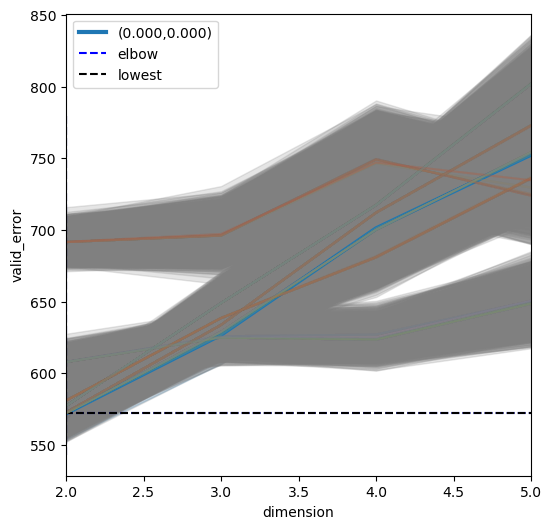

In [16]:
optimal_MF_data, optimal_stat, embed_stat_list = clf.detect_dimension(MF_data,
                    dimension_list=[2,3,4,5],
                    W_beta_list=[0.0,0.01,0.1,0.2,0.5,1],
                    Q_beta_list=[0.0,0.01,0.1,0.2,0.5,1],
                    repeat=5, nfold=10,
                    random_fold=False,
                    separate_beta=True,
                    detection='kneed')

Print the selected hyper-parameter values:

In [17]:
print('++ INFO [ICQF hyper-parameter optimization]: d=%d' % clf.n_components)
print('++ INFO:[ICQF hyper-parameter optimization]: W_beta=%0.2f' % clf.W_beta)
print('++ INFO:[ICQF hyper-parameter optimization]: Q_beta=%0.2f' % clf.Q_beta)

++ INFO [ICQF hyper-parameter optimization]: d=2
++ INFO:[ICQF hyper-parameter optimization]: W_beta=0.00
++ INFO:[ICQF hyper-parameter optimization]: Q_beta=0.00


Save the results of the optimization to disk

In [18]:
data_to_save = {'optimal_MF_data': optimal_MF_data, 'optimal_stat':optimal_stat, 'embed_stat_list': embed_stat_list,'clf':clf}
with open('../resources/snycq/SNYCQ_icqf_results.pkl', 'wb') as file:
    pickle.dump(data_to_save, file)

## 3.3. Extract results obtainecd with optimal hyper-parameters

In [19]:
DIM = clf.n_components
Q = pd.DataFrame(optimal_MF_data.Q, index=SNYCQ_items, columns=['Factor {d}'.format(d=d+1) for d in range(DIM)])
W = pd.DataFrame(optimal_MF_data.W, index=SNYCQ.index, columns=['Factor {d}'.format(d=d+1) for d in range(DIM)])
C = pd.DataFrame(optimal_MF_data.C, index=SNYCQ.index, columns=['Age (elder)','Gender (M)','Age (younger)','Gender (F)','Intercept'])
C = C[['Intercept','Age (younger)','Age (elder)','Gender (M)','Gender (F)']] # Sorting to make it more interpretable

Qc = pd.DataFrame(optimal_MF_data.Qc, index=SNYCQ.columns, columns = ['Age (elder)','Gender (M)','Age (younger)','Gender (F)','Intercept'])
Qc = Qc[['Intercept','Age (younger)','Age (elder)','Gender (M)','Gender (F)']] # Sorting to make it more interpretable

***
Plot the W matrix

In [ ]:
W_Supp_Fig = pd.concat([W, pd.DataFrame(index=W.index,columns=C.columns)],axis=1)
W_plot = W_Supp_Fig.reset_index(drop=True).hvplot.heatmap(cmap='Greens', width=300, height=550, fontscale=1.2, clim=(0,1), shared_axes=False).opts( colorbar_opts={'title':'W Matrix'}, xrotation=90, toolbar=None)
hv.save(W_plot, osp.join('figures', 'Supplementary_Figure05W.html'), backend='bokeh')
W_plot

:HeatMap   [columns,index]   (value)

![W](./figures/Supplementary_Figure04_W.png)

Plot the C matrix

In [ ]:
C_Supp_Fig = pd.concat([pd.DataFrame(index=C.index,columns=W.columns), C],axis=1)
C_plot = C_Supp_Fig.reset_index(drop=True).hvplot.heatmap(cmap='Purples', width=300, height=550, fontscale=1.2, clim=(0,1), shared_axes=False).opts( colorbar_opts={'title':'C Matrix'}, xrotation=90, toolbar=None)
hv.save(C_plot, osp.join('figures', 'Supplementary_Figure05_C.html'), backend='bokeh')
C_plot

:HeatMap   [columns,index]   (value)

![C](./figures/Supplementary_Figure04_C.png)

Plot the Q matrix

In [ ]:
Q_Supp_Fig = pd.concat([Q, pd.DataFrame(index=Q.index,columns=C.columns)],axis=1)
Q_plot = Q_Supp_Fig.hvplot.heatmap(cmap='Oranges', width=300, height=550, fontscale=1.2, clim=(0,100), shared_axes=False).opts( colorbar_opts={'title':'Q Matrix'}, xrotation=90, toolbar=None)
hv.save(Q_plot, osp.join('figures', 'Supplementary_Figure05_Q.html'), backend='bokeh')
Q_plot

:HeatMap   [columns,index]   (value)

![Q](./figures/Supplementary_Figure04_Q.png)

Plot Qc

In [ ]:
Qc_Supp_Fig = pd.concat([pd.DataFrame(index=Qc.index,columns=Q.columns),Qc],axis=1)
Qc_plot = Qc_Supp_Fig.hvplot.heatmap(cmap='Oranges', width=300, height=550, fontscale=1.2, clim=(0,100), shared_axes=False).opts( colorbar_opts={'title':'Q Matrix'}, xrotation=90, toolbar=None)
hv.save(Qc_plot, osp.join('figures', 'Supplementary_Figure05_Qc.html'), backend='bokeh')
Qc_plot

:HeatMap   [columns,index]   (value)

![Qc](./figures/Supplementary_Figure04_Qc.png)

***

# 4. Plot scans in ICQF space 

Next, we will generate a scatter plot where each scan is represented by a point in the 2D ICQF space. Scans will be colored according to Set Membership previously stablished by performing Gaussian Misture Modeling of the data in the original 11D space.

In [33]:
W_wSetLabels = pd.concat([W,emb_plus['Set Label']],axis=1)

In [25]:
W_scat = W_wSetLabels.hvplot.scatter(
    x='Factor 1',
    y='Factor 2',
    aspect='square',
    color='Set Label',
    cmap=["#ff7f0e", "#ffffff", "#1f77b4"],
    legend='bottom_left',
    line_color='black',
    line_width=0.5,
    alpha=0.7
).opts(
        fontsize={
            'ticks': 12,
            'labels': 14,
            'legend': 14,
            'title': 16
        }
    ,toolbar=None)
hv.save(W_scat, osp.join('figures', 'Figure01_C-SNYCQ_ICQF_Scatter.html'), backend='bokeh')
W_scat

:Scatter   [Factor 1]   (Factor 2,Set Label)

![W Scatter Plot](./figures/Figure01_C-SNYCQ_ICQF_Scatter.png)

## 4.1. Heatmap with relationship between Factor 1 (TP1) and original sNYCQ items 

In [26]:
F1_vals_to_plot = pd.DataFrame(Q.sort_values(by='Factor 1', ascending=True)['Factor 1'].round(0).astype(int)).T
f = F1_vals_to_plot.hvplot.heatmap(cmap='Bone', clim=(0,110), width=700, height=175,colorbar=False, yaxis=None).opts(toolbar=None, line_color='k', line_width=1)
TP1_vector = f * hv.Labels(f).opts(opts.Labels(text_color='white', xrotation=45, fontsize={'labels':12,'xticks':14}))
hv.save(TP1_vector, osp.join('figures', 'Figure01_D-SNYCQ_ICQF_TP1_Values.html'), backend='bokeh')
TP1_vector

:Overlay
   .HeatMap.I :HeatMap   [columns,index]   (value)
   .Labels.I  :Labels   [columns,index]   (value)

![TP1 Values](./figures/Figure01_D-SNYCQ_ICQF_TP1_Values.png)

## 4.2. Heatmap with relationship between Factor 2 (TP2) and original sNYCQ items

In [27]:
F2_vals_to_plot = pd.DataFrame(Q.sort_values(by='Factor 2', ascending=True)['Factor 2'].round(0).astype(int))
f = F2_vals_to_plot.hvplot.heatmap(cmap='Bone', clim=(0,110), width=200, height=700,colorbar=False, xaxis=None).opts(toolbar=None, line_color='k', line_width=1)
TP2_vector = f * hv.Labels(f).opts(opts.Labels(text_color='white', xrotation=45, fontsize={'labels':12,'yticks':14}))
hv.save(TP2_vector, osp.join('figures', 'Figure01_E-SNYCQ_ICQF_TP2_Values.html'), backend='bokeh')
TP2_vector

:Overlay
   .HeatMap.I :HeatMap   [columns,index]   (value)
   .Labels.I  :Labels   [columns,index]   (value)

![TP2 Values](./figures/Figure01_D-SNYCQ_ICQF_TP2_Values.png)

## 4.3 Plot examples of scans sitting on both corners of the embedding

In [28]:
sorted_q = Q.sort_values(by=['Factor 1','Factor 2'],ascending=False).index

In [30]:
top_left_scans = W[(W['Factor 1']<0.35) & (W['Factor 2']>0.9)].index
a = SNYCQ.loc[top_left_scans].reset_index(drop=True)
top_left_scans_plot = a[sorted_q].hvplot.heatmap(width=250, height=250, clim=(0,100), cmap='Viridis', ylabel='Scan', xlabel='Question', fontscale=1.2).opts(colorbar=False, xrotation=90, toolbar=None)
hv.save(top_left_scans_plot, osp.join('figures', 'Figure01_C-SNYCQ_ICQF_TopLeftScans.html'), backend='bokeh')
top_left_scans_plot

:HeatMap   [columns,index]   (value)

![Top Left Scans](./figures/Figure01_C-SNYCQ_ICQF_TopLeftScans.png)

In [31]:
bot_right_scans = W[(W['Factor 1']>0.9) & (W['Factor 2']<0.1)].index
a = SNYCQ.loc[bot_right_scans].reset_index(drop=True)
bot_right_scans_plot = a[sorted_q].hvplot.heatmap(width=250, height=250, clim=(0,100), cmap='Viridis', ylabel='Scan', xlabel='Question', fontscale=1.2).opts(colorbar=False, xrotation=90, toolbar=None)
hv.save(bot_right_scans_plot, osp.join('figures', 'Figure01_C-SNYCQ_ICQF_BotRightScans.html'), backend='bokeh')
bot_right_scans_plot

:HeatMap   [columns,index]   (value)

![Bottom Right Scans](./figures/Figure01_C-SNYCQ_ICQF_BotRightScans.png)

Save ICQF embedding to disk

In [32]:
W.to_csv('../resources/snycq/SNYCQ_W.csv')